In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif as MIC, SelectKBest
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as ttsv
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectPercentile as SP
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin

In [62]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("impute_mean_classes_new.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

((4066, 78), (4066,))

In [24]:
df_numeric['u']

0      -3.855836
1      -3.855836
2      -0.631608
3      -3.196994
4      -3.196994
          ...   
4061    6.943396
4062    6.943396
4063    6.943396
4064    6.943396
4065    6.943396
Name: u, Length: 4066, dtype: float64

In [100]:
# calculate mutual information
scores = mutual_info_classif(X, y, random_state = 24)

X_new = SelectKBest(mutual_info_classif, k=10).fit(X, y)
print(X_new.get_feature_names_out())
#fs = SelectKBest(score_func=mutual_info_classif, k=50)
#fs
print('scores:', scores)

# Alle scores
all_scores = X_new.scores_

#Hent index for de 5 bedste features
top5_indices = X_new.get_support(indices=True)

# Hent de 5 score værdier
top5_scores = all_scores[top5_indices]

# (Valgfrit) Hent feature-navne hvis X er DataFrame
top5_feature_names = X.columns[top5_indices]

# Print
for name, score in zip(top5_feature_names, top5_scores):
    print(f"{name}: {score:.4f}")

['ammonium' 'ammonium std' 'nitrite' 'nitrite std' 'nitrate' 'depth bathy'
 'distance closest' 'iron' 'radiation 30' 'sea surface temp']
scores: [0.47878021 0.48028402 0.47409968 0.47926231 0.46936039 0.11340901
 0.47314711 0.44493943 0.47365514 0.44417195 0.47939405 0.06679315
 0.0735671  0.45073966 0.18317629 0.32375108 0.46879453 0.17974971
 0.3281122  0.37148961 0.22189194 0.20456337 0.17131205 0.19252746
 0.20655708 0.21885816 0.14224893 0.14060377 0.13601991 0.14519265
 0.18271696 0.47628917 0.02488226 0.05036166 0.00645184 0.4350083
 0.40860096 0.46652805 0.40768132 0.47204187 0.1958153  0.18862115
 0.18605592 0.19875155 0.23105701 0.29862052 0.31490249 0.21848678
 0.07332014 0.0113269  0.04946039 0.0560595  0.03637351 0.25786879
 0.23099846 0.21943586 0.22213431 0.24390565 0.06157813 0.06718036
 0.0634862  0.1637459  0.15876342 0.15317446 0.15869068 0.15706155
 0.15851056 0.3757529  0.29478384 0.02139636 0.41364654 0.41024819
 0.4527673  0.47193625 0.34661231 0.44987217 0.44288

In [73]:
# 1. First select features
mi_score_selected_index = np.where(mi_scores >0.23)[0]
X_2 = X.iloc[:,mi_score_selected_index]

# prepare dataset 3, MI <0.2
mi_score_selected_index = np.where(mi_scores > 0.25)[0]
X_3 = X.iloc[:,mi_score_selected_index]

X_train_3,X_test_3,y_train_3,y_test_3 = tts(
    X_3,y,random_state=0,stratify=y)

# 2. Then split
X_train, X_test, y_train, y_test = train_test_split(
    X_2, y, test_size=0.2, random_state=42
)

knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

# 3. Now train and test will have matching features
model_1 = clf.fit(X_train, y_train)
print(model_1.score(X_test, y_test))  # This should work now
print(X_2.shape)
model_2 = clf.fit(X_train_3, y_train_3)
print(model_2.score(X_test_3, y_test_3))  # This should work now
print(X_3.shape)

# use Scikit-learn feature selector
selector = SP(percentile=50) # select features with top 50% MI scores
selector.fit(X,y)
X_4 = selector.transform(X)
X_train_4,X_test_4,y_train,y_test = tts(
    X_4,y,random_state=0,stratify=y)

model_4 = clf.fit(X_train_4,y_train)
score_4 = model_4.score(X_test_4,y_test)
print(score_4)
print(X_4.shape)

0.952088452088452
(4066, 34)
0.9547689282202556
(4066, 32)
0.9311701081612586
(4066, 39)


In [78]:
from sklearn.base import BaseEstimator, TransformerMixin

knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

class MutualInfoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.1):
        self.threshold = threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        mi_scores = mutual_info_classif(X, y)
        self.selected_features_ = np.where(mi_scores > self.threshold)[0]
        return self
    
    def transform(self, X):
        return X.iloc[:, self.selected_features_]

# Create pipeline
pipe = Pipeline([
    ('selector', MutualInfoSelector()),
    ('clf', clf)  # Your classifier
])

# Grid search parameters
param_grid = {
    'selector__threshold': np.linspace(0, 0.5, 20)
}

grid_search = HalvingGridSearchCV(pipe, param_grid, cv = 5, scoring='accuracy', random_state = 43)
grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# After fitting
print("\nHalving process summary:")
print(f"Total candidates: {len(grid_search.cv_results_['params'])}")
print(f"Number of iterations: {grid_search.n_iterations_}")
print(f"Resources per iteration: {grid_search.n_resources_}")
print(grid_search.cv_results_)

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
39 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
39 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_es

Best parameters: {'selector__threshold': 0.23684210526315788}
Best score: 0.9610454769092467

Halving process summary:
Total candidates: 30
Number of iterations: 3
Resources per iteration: [451, 1353, 4059]
{'iter': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2]), 'n_resources': array([ 451,  451,  451,  451,  451,  451,  451,  451,  451,  451,  451,
        451,  451,  451,  451,  451,  451,  451,  451,  451, 1353, 1353,
       1353, 1353, 1353, 1353, 1353, 4059, 4059, 4059]), 'mean_fit_time': array([0.22884521, 0.22709212, 0.27971992, 0.25128751, 0.21672301,
       0.22231178, 0.30890703, 0.24016352, 0.22554607, 0.22231598,
       0.21865554, 0.36117949, 0.28001518, 0.25099764, 0.26213617,
       0.30171275, 0.24391713, 0.28959112, 0.31890035, 0.23232503,
       0.61145487, 0.60108342, 0.62741442, 0.48340149, 0.55076704,
       0.55191188, 0.54644771, 1.82119608, 1.69502268, 1.76674953]), 'std_fit_time': array([0.0136221 , 0.01

In [80]:
df = pd.DataFrame(grid_search.cv_results_)
df

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__threshold,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0,451,0.228845,0.013622,0.015242,0.005193,0.000000,{'selector__threshold': 0.0},0.766667,0.911111,...,0.857778,0.049391,19,0.891667,0.900000,0.875000,0.872222,0.886111,0.885000,0.010334
1,0,451,0.227092,0.010814,0.011808,0.006561,0.026316,{'selector__threshold': 0.02631578947368421},0.811111,0.911111,...,0.873333,0.034854,12,0.894444,0.891667,0.883333,0.891667,0.897222,0.891667,0.004648
2,0,451,0.279720,0.054706,0.016113,0.005230,0.052632,{'selector__threshold': 0.05263157894736842},0.811111,0.911111,...,0.862222,0.032660,17,0.902778,0.902778,0.886111,0.888889,0.905556,0.897222,0.008051
3,0,451,0.251288,0.048592,0.011859,0.006148,0.078947,{'selector__threshold': 0.07894736842105263},0.822222,0.911111,...,0.871111,0.029481,14,0.905556,0.925000,0.905556,0.894444,0.894444,0.905000,0.011167
4,0,451,0.216723,0.006172,0.014309,0.001885,0.105263,{'selector__threshold': 0.10526315789473684},0.811111,0.888889,...,0.871111,0.031895,14,0.922222,0.925000,0.900000,0.897222,0.905556,0.910000,0.011467
5,0,451,0.222312,0.006364,0.010538,0.008827,0.131579,{'selector__threshold': 0.13157894736842105},0.822222,0.911111,...,0.875556,0.036107,11,0.916667,0.905556,0.925000,0.905556,0.919444,0.914444,0.007738
6,0,451,0.308907,0.060151,0.011447,0.006171,0.157895,{'selector__threshold': 0.15789473684210525},0.866667,0.911111,...,0.873333,0.025915,12,0.927778,0.905556,0.911111,0.902778,0.908333,0.911111,0.008784
7,0,451,0.240164,0.015577,0.011055,0.005232,0.184211,{'selector__threshold': 0.18421052631578946},0.822222,0.866667,...,0.855556,0.017213,20,0.911111,0.919444,0.913889,0.908333,0.891667,0.908889,0.009362
8,0,451,0.225546,0.007112,0.006032,0.009191,0.210526,{'selector__threshold': 0.21052631578947367},0.811111,0.855556,...,0.860000,0.029481,18,0.925000,0.905556,0.902778,0.913889,0.919444,0.913333,0.008315
9,0,451,0.222316,0.010890,0.004948,0.005776,0.236842,{'selector__threshold': 0.23684210526315788},0.755556,0.911111,...,0.866667,0.057948,16,0.902778,0.902778,0.908333,0.894444,0.919444,0.905556,0.008240


In [94]:
knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

class MutualInfoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.1):
        self.threshold = threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        mi_scores = mutual_info_classif(X, y, random_state = 42)
        self.selected_features_ = np.where(mi_scores > self.threshold)[0]
        return self
    
    def transform(self, X):
        return X.iloc[:, self.selected_features_]

# Create pipeline
pipe = Pipeline([
    ('selector', MutualInfoSelector()),
    ('clf', clf)  # Your classifier
])

# Grid search parameters
param_grid = {
    'selector__threshold': np.linspace(0, 0.5, 20)
}

grid_search = GridSearchCV(pipe, param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X, y)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# After fitting

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
6 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_esti

(4066, 78)
Best parameters: {'selector__threshold': 0.4473684210526315}
Best score: 0.9645853166148368


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.662136,0.072904,0.077792,0.009107,0.000000,{'selector__threshold': 0.0},0.934889,0.920049,0.937269,0.934809,0.926199,0.930643,0.006500,18
1,1.595885,0.031808,0.080574,0.007862,0.026316,{'selector__threshold': 0.02631578947368421},0.936118,0.921279,0.943419,0.931119,0.926199,0.931627,0.007694,16
2,1.653828,0.141606,0.078574,0.018306,0.052632,{'selector__threshold': 0.05263157894736842},0.936118,0.921279,0.942189,0.933579,0.924969,0.931627,0.007576,16
3,1.815547,0.191142,0.092198,0.019964,0.078947,{'selector__threshold': 0.07894736842105263},0.937346,0.921279,0.947109,0.934809,0.926199,0.933349,0.008992,15
4,1.674362,0.117128,0.083444,0.013863,0.105263,{'selector__threshold': 0.10526315789473684},0.937346,0.926199,0.947109,0.934809,0.926199,0.934333,0.007808,13
5,1.706056,0.135979,0.080972,0.014250,0.131579,{'selector__threshold': 0.13157894736842105},0.937346,0.927429,0.944649,0.933579,0.924969,0.933595,0.007053,14
6,1.771706,0.154074,0.089384,0.016428,0.157895,{'selector__threshold': 0.15789473684210525},0.937346,0.934809,0.954490,0.947109,0.939729,0.942697,0.007186,12
7,1.760188,0.179951,0.095760,0.017011,0.184211,{'selector__threshold': 0.18421052631578946},0.954545,0.945879,0.956950,0.945879,0.940959,0.948843,0.005966,11
8,1.750204,0.230358,0.097777,0.030269,0.210526,{'selector__threshold': 0.21052631578947367},0.960688,0.952030,0.963100,0.956950,0.947109,0.955975,0.005798,10
9,1.683332,0.086927,0.082005,0.008004,0.236842,{'selector__threshold': 0.23684210526315788},0.960688,0.963100,0.972940,0.958180,0.949569,0.960895,0.007558,8


In [93]:
# 1. First select features
mi_score_selected_index = np.where(mi_scores >0.4473)[0]
X_2 = X.iloc[:,mi_score_selected_index]
X_2

,ammonium,ammonium std,nitrite,nitrite std,nitrate,depth bathy,distance closest,iron,latitude.1,longitude.1,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,u
2378,0.011647,0.001062,0.006479,0.001361,4.039602,-4931.000000,454.550900,0.000004,-15.017600,-148.266700,1.021912,46.347424,45.408386,0.245140,26.686632,-16.740450
2420,0.019421,0.014966,0.036846,0.047819,5.954987,-4387.000000,375.721400,0.000003,-5.633300,-155.863000,1.244382,50.930030,54.287350,0.167470,27.159315,-25.670296
1940,0.018831,0.007324,0.057298,0.028184,1.940813,-2738.748483,280.319635,0.000945,16.714123,-4.531674,0.654520,52.996185,53.979880,1.040722,24.200793,6.943396
1592,0.040871,0.012805,0.175246,0.095507,11.336968,-5030.000000,41.390200,0.000004,-34.166700,-72.024700,1.000068,40.447495,43.392790,2.105800,18.466765,4.738948
2283,0.025083,0.011750,0.054778,0.047893,6.231764,-896.000000,5.445200,0.000002,-8.900000,-140.227600,0.853389,46.940914,45.790096,1.040722,26.730190,-4.286042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.012845,0.000930,0.029691,0.004530,0.012457,-3722.000000,544.170300,0.001244,-7.966700,-14.317700,0.004551,47.209393,43.349780,0.255560,23.675053,-5.488986
1294,0.012506,0.006803,0.005806,0.004141,0.003165,-1031.000000,155.558600,0.000805,-23.373000,-44.566700,0.002556,52.275124,54.200054,2.000300,24.192727,-12.666875
860,0.012245,0.000652,0.002289,0.000248,0.014058,-3361.000000,70.118100,0.001074,-12.839200,47.566700,0.004599,41.299805,41.682808,0.282200,29.767761,-2.028967
3507,0.014199,0.009693,0.025725,0.011551,8.367322,-2738.748483,280.319635,0.000990,16.714123,-4.531674,3.924304,30.019270,30.199345,1.040722,4.301265,-0.606857


(3252, 78) (3252,) (814, 78) (814,)
cross validation scores: [0.93488943 0.9200492  0.93726937 0.93480935 0.92619926]
0.9306 accuracy with a standard deviation of 0.0065
Accuracy: 93.00%
Score: 93.00%
[[628  21   1   0]
 [ 23 106   4   0]
 [  3   4  23   0]
 [  0   0   1   0]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       650
           1       0.81      0.80      0.80       133
           2       0.79      0.77      0.78        30
           3       0.00      0.00      0.00         1

    accuracy                           0.93       814
   macro avg       0.64      0.63      0.64       814
weighted avg       0.93      0.93      0.93       814



C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

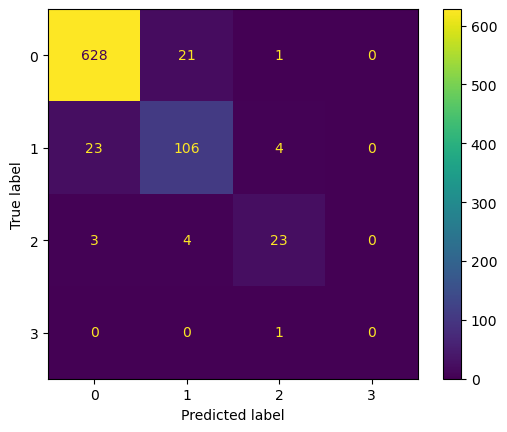

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape,
X_test.shape, y_test.shape)

KNN = KNeighborsClassifier()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNN)]
)
clf.fit(X_train, y_train)

cross_val_scores = cross_val_score(clf, X, y, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

score = clf.score(X_test, y_test)
print(f"Score: {score * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))